# Project 13. Emoticons generation Analysis

## 1. Find the dataset

A dataset where each emoticon is assigned the corresponding text: [cheatsnake/emojihub · GitHub](https://github.com/cheatsnake/emojihub)

Also the api: `https://emojihub.yurace.pro/api/all`

## 2. Process emojis and match them with EmoTag1200

In [ ]:
!pip install gensim scipy matplotlib nltk numpy pandas

### Process emoji definitions into vectors

In [1]:
import json
import re
import numpy as np
from urllib.request import urlopen

def load_embedding_model():
    import gensim.downloader as api
    print("Loading word2vec-google-news-300 ... (≈1.6GB)")
    model = api.load("word2vec-google-news-300")
    dim = 300
    return model, dim

_token_re = re.compile(r"[A-Za-z]+")

def tokenize(text: str):
    return [t.lower() for t in _token_re.findall(text)]

def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def text_to_vec(text: str, model, dim: int):
    """
    convert text into vectors using w2v

    params:
        text: the text string to process
        model: the model used to convert text to vec
        dim: dimention of vector
    """
    toks = tokenize(text)
    vecs = []
    for w in toks:
        if w in model:
            vecs.append(model[w])
    if not vecs:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(np.vstack(vecs), axis=0).astype(np.float32)

def load_emoji_definitions(json_url: str):
    """
    load emoji definitions from api
    """
    with urlopen(json_url) as resp:
        data_str = resp.read().decode()
        return json.loads(data_str)

def match_emoji_definition(emoji_unicode: str, data: list):
    """
    get emoji definitions from dataset

    params: 
        emoji_unicode: unicode of the emoji want to process
        data: json dataset of emoji definitions
    """
    target_unicode = "U+" + emoji_unicode
    match = [item["name"] for item in data if target_unicode in item["unicode"]]
    return match[0]

def emoji_definition_vector(emoji_unicode: str, data, model, dim: int):
    """
    convert emoji definition to vector
    
    params:
        emoji_unicode: unicode of the emoji want to process
        model: the model used to convert text to vec
        dim: dimention of vector
    """
    definition = match_emoji_definition(emoji_unicode, data)
    vec = text_to_vec(definition, model, dim)
    return vec, definition

def emoji_emotion_similarity(emoji_unicode: str, data, model, dim: int):
    """
    calculate similarity of emoji definition to each emotions

    params:
        emoji_unicode: unicode of the emoji want to process
        model: the model used to convert text to vec
        dim: dimention of vector
    """
    emotions = ["anger", "anticipation", "disgust", "fear", "joy", "sadness", "surprise", "trust"]

    result = []
    for emotion in emotions:
        emotion_vec = text_to_vec(emotion, model, dim)
        emoji_vec, definitoin = emoji_definition_vector(emoji_unicode, data, model, dim)
        #print(emoji_vec)
        similarity = cosine_similarity(emoji_vec, emotion_vec)
        result.append(similarity)
    
    return result

def get_csv_data(url: str):
    return pd.read_csv(url)

def match_emotag(emoji_unicode: str, df):
    result = df[df["unicode"] == emoji_unicode].iloc[0, 3:].to_numpy()
    return result

### Compare emoji definition with Emotag using pearson correlation

Loading word2vec-google-news-300 ... (≈1.6GB)
           emoji  pearson_r   p_value
0        rainbow   0.271190  0.515899
1  crescent moon  -0.296659  0.475538
2  new moon face   0.202063  0.631317
3  sun with face   0.353910  0.389747
4   glowing star   0.371975  0.364211
Mean r = 0.1674455991222437
Median r = 0.2050820759336442


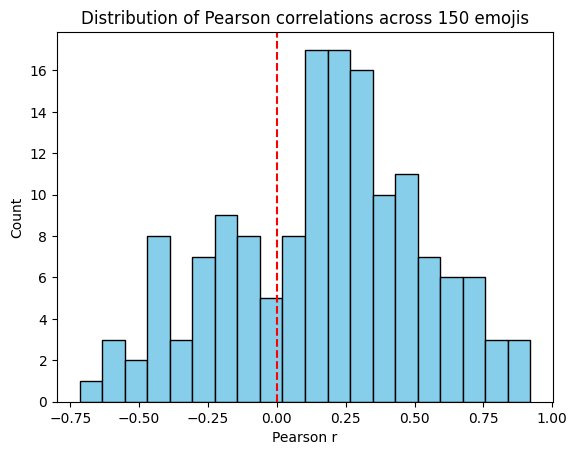

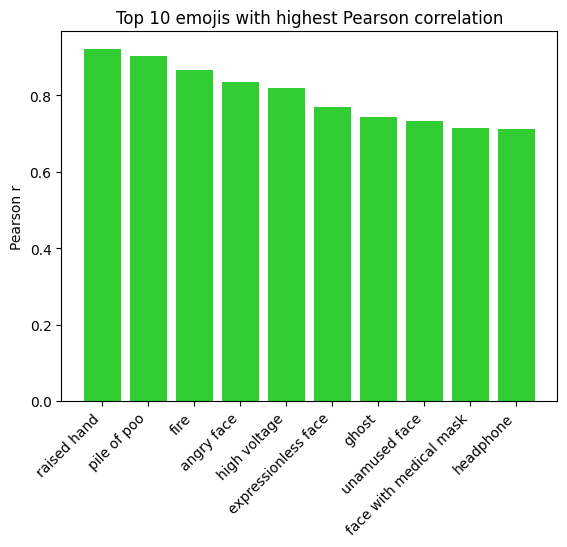

In [4]:
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import matplotlib as mpl

def compute_pearson(df, data, model, dim):
    """
    compute pearson correlation between calculated emoji result and EmoTag

    params:
        df: datafram of EmoTag csv data
        data: emoji definition json data
        model: the model used to convert text to vec
        dim: dimention of vector
    """
    results = []
    for index, row in df.iterrows():
        res = row.iloc[3:].to_numpy()
        sim = emoji_emotion_similarity(row["unicode"], data, model, dim)
        r, pval = pearsonr(res, sim)
        results.append({"emoji": row["name"], 'pearson_r': r, 'p_value': pval})

    return pd.DataFrame(results)

def plot_result(results_df):
    """
    plot compute result

    params:
        results_df: pearson correlation result dataframe
    """
    print(results_df.head())
    print("Mean r =", results_df['pearson_r'].mean())
    print("Median r =", results_df['pearson_r'].median())

    # draw plot
    plt.hist(results_df['pearson_r'], bins=20, color='skyblue', edgecolor='k')
    plt.title('Distribution of Pearson correlations across 150 emojis')
    plt.xlabel('Pearson r')
    plt.ylabel('Count')
    plt.axvline(0, color='red', linestyle='--')
    plt.show()

    # emoji_font = FontProperties(fname="/usr/share/fonts/noto/NotoColorEmoji.ttf")
    top10 = results_df.sort_values('pearson_r', ascending=False).head(10)
    plt.bar(top10['emoji'], top10['pearson_r'], color='limegreen')
    plt.title('Top 10 emojis with highest Pearson correlation')
    plt.ylabel('Pearson r')
    plt.xticks(rotation=45, ha='right')
    plt.show()


if __name__ == "__main__":
    EMOTAG_URL = "https://raw.githubusercontent.com/abushoeb/EmoTag/refs/heads/master/data/EmoTag1200-scores.csv"
    EMOJI_DEFINITION_URL = "https://emojihub.yurace.pro/api/all"

    model, dim = load_embedding_model()

    df = get_csv_data(EMOTAG_URL)
    data = load_emoji_definitions(EMOJI_DEFINITION_URL)
    
    results_df = compute_pearson(df, data, model, dim)
    plot_result(results_df)

### 3. Compare result of different embedding strategies

PLOT OF GloVe MODEL:
Loading glove-wiki-gigaword-100 ... (≈128MB)
           emoji  pearson_r   p_value
0        rainbow   0.792307  0.019054
1  crescent moon   0.271716  0.515053
2  new moon face  -0.421242  0.298632
3  sun with face  -0.020211  0.962116
4   glowing star   0.447241  0.266536
Mean r = 0.11050485239900176
Median r = 0.10315479462983432


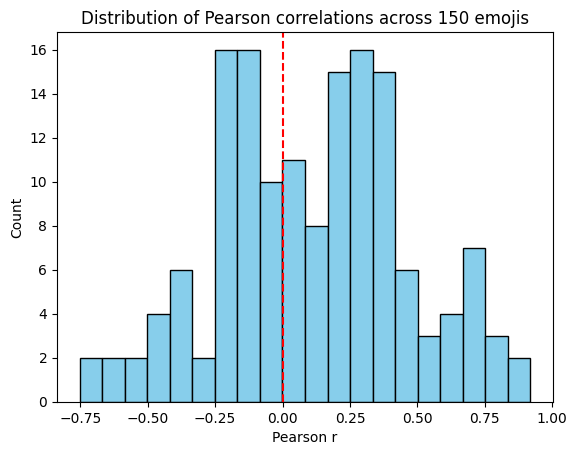

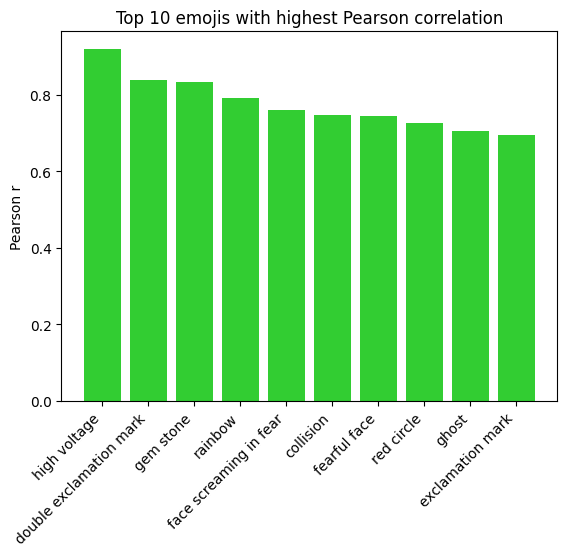

PLOT OF FastText MODEL:
Loading fasttext-wiki-news-subwords-300 ... (≈958MB)
           emoji  pearson_r   p_value
0        rainbow   0.777787  0.023063
1  crescent moon   0.310311  0.454439
2  new moon face  -0.162926  0.699876
3  sun with face  -0.048512  0.909183
4   glowing star   0.848535  0.007730
Mean r = 0.2870921779982472
Median r = 0.3321520522757172


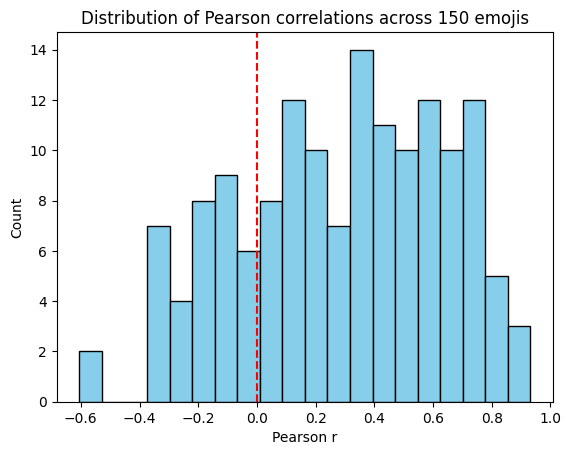

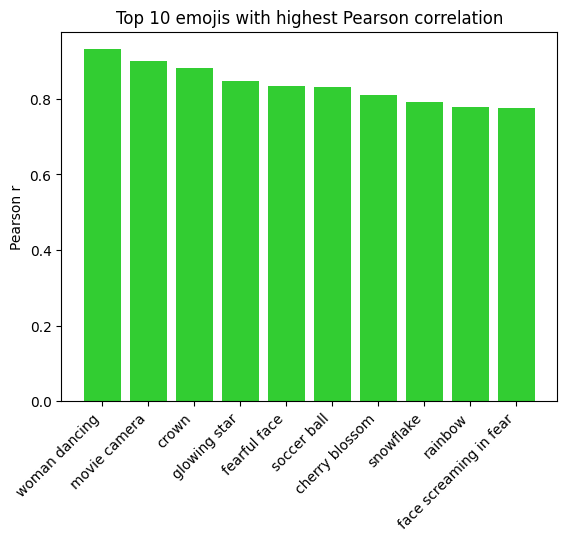

In [8]:
def load_other_embedding_model(model_name: str):
    import gensim.downloader as api
    if model_name == "glove":
        print("Loading glove-wiki-gigaword-100 ... (≈128MB)")
        model = api.load("glove-wiki-gigaword-100")
        dim = 100
    elif model_name == "fasttext":
        print("Loading fasttext-wiki-news-subwords-300 ... (≈958MB)")
        model = api.load("fasttext-wiki-news-subwords-300")
        dim = 100
    return model, dim


def run(model):
    EMOTAG_URL = "https://raw.githubusercontent.com/abushoeb/EmoTag/refs/heads/master/data/EmoTag1200-scores.csv"
    EMOJI_DEFINITION_URL = "https://emojihub.yurace.pro/api/all"

    model, dim = load_other_embedding_model(model)

    df = get_csv_data(EMOTAG_URL)
    data = load_emoji_definitions(EMOJI_DEFINITION_URL)
    
    results_df = compute_pearson(df, data, model, dim)
    plot_result(results_df)

if __name__ == "__main__":
    print("PLOT OF GloVe MODEL:")
    run("glove")
    print("PLOT OF FastText MODEL:")
    run("fasttext")